<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [2]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Datos
Utilizaremos como dataset canciones de bandas de habla inglés.

In [3]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [4]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [5]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' en el año 1872, la casa número 7 de saville-row, burlington gardens \n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\n pesar de que parecía haber tomado el partido de no hacer nada que \npudiese llamar la atención, era uno de los miembros más notables y \nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \nninguno de los despachos mercantiles de la city. ni las dársenas

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [6]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [7]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [8]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [9]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

67

In [10]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [11]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [12]:
tokenized_text[:1000]

[64,
 61,
 22,
 64,
 61,
 17,
 64,
 13,
 47,
 0,
 64,
 59,
 28,
 55,
 56,
 38,
 64,
 17,
 13,
 64,
 48,
 13,
 33,
 13,
 64,
 22,
 5,
 26,
 61,
 50,
 0,
 64,
 55,
 64,
 57,
 61,
 64,
 33,
 13,
 43,
 65,
 17,
 17,
 61,
 11,
 50,
 0,
 58,
 38,
 64,
 45,
 42,
 50,
 17,
 65,
 22,
 12,
 51,
 0,
 22,
 64,
 12,
 13,
 50,
 57,
 61,
 22,
 33,
 64,
 34,
 24,
 57,
 0,
 22,
 57,
 61,
 64,
 26,
 42,
 50,
 65,
 21,
 64,
 33,
 1,
 61,
 50,
 65,
 57,
 13,
 22,
 64,
 61,
 22,
 64,
 59,
 28,
 59,
 36,
 24,
 64,
 61,
 33,
 51,
 13,
 45,
 13,
 64,
 1,
 13,
 45,
 65,
 51,
 13,
 57,
 13,
 64,
 32,
 0,
 50,
 64,
 32,
 1,
 65,
 17,
 61,
 13,
 33,
 64,
 2,
 0,
 12,
 12,
 38,
 64,
 19,
 42,
 65,
 61,
 22,
 64,
 13,
 34,
 64,
 32,
 61,
 33,
 13,
 50,
 64,
 57,
 61,
 64,
 19,
 42,
 61,
 64,
 32,
 13,
 50,
 61,
 48,
 31,
 13,
 64,
 1,
 13,
 45,
 61,
 50,
 64,
 51,
 0,
 26,
 13,
 57,
 0,
 64,
 61,
 17,
 64,
 32,
 13,
 50,
 51,
 65,
 57,
 0,
 64,
 57,
 61,
 64,
 22,
 0,
 64,
 1,
 13,
 48,
 61,
 50,
 64,
 22,
 13,
 57

### Organizando y estructurando el dataset

In [13]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [14]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [15]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [16]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [17]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [18]:
X.shape

(355829, 100)

In [19]:
X[0,:10]

array([64, 61, 22, 64, 61, 17, 64, 13, 47,  0])

In [20]:
y[0,:10]

array([61, 22, 64, 61, 17, 64, 13, 47,  0, 64])

In [21]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [22]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [23]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

/Users/spardo/projects/esp-ai/pln/procesamiento_lenguaje_natural/.venv/lib/python3.11/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        53,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 67)       │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,067 (261.98 KB)

 Trainable params: 67,067 (261.98 KB)

 Non-trainable params: 0 (0.00 B)


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [24]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento

In [25]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

Epoch 1/20


TypeError: Exception encountered when calling TimeDistributed.call().

[1mFailed to convert elements of (None,) to Tensor. Consider casting elements to a supported type. See https://www.tensorflow.org/api_docs/python/tf/dtypes for supported TF dtypes.[0m

Arguments received by TimeDistributed.call():
  • inputs=tf.Tensor(shape=(None, 100, 1), dtype=float32)
  • training=True
  • mask=None

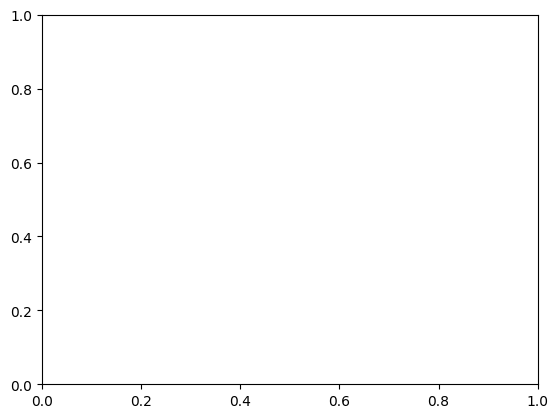

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

In [27]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model = keras.models.load_model('my_model.keras')


### Predicción del próximo caracter

In [28]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

zsh:1: command not found: pip


In [30]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Keyboard interruption in main thread... closing server.


### Generación de secuencias

In [31]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [32]:
input_text='habia una vez'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

'habia una vezo?ñúy:bt—39ñ/9c¡y—10b9tñ9/¡9c:'

###  Beam search y muestreo aleatorio

In [33]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [34]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [35]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="habia una vez")

In [36]:
salidas[0]

array([ 1, 13, 45, 65, 13, 64, 42, 22, 13, 64, 43, 61, 54,  0, 30, 47,  5,
        3, 15, 45, 51, 24, 44, 25,  3, 24, 48, 52,  3, 15, 30, 59, 47])

In [37]:
# veamos las salidas
decode(salidas[0])

'habia una vezo?ñúy:bt—39y—c¡y:?1ñ'

---
## Resolución

**Corpus elegido**: canciones de Bob Dylan (disponible localmente en `songs_dataset/bob-dylan.txt`). Se elige porque ofrece un vocabulario de caracteres compacto, estructura lírica repetitiva y patrones estilísticos reconocibles, lo que facilita evaluar la coherencia de las secuencias generadas.

In [38]:
with open('songs_dataset/bob-dylan.txt', 'r', encoding='utf-8') as f:
    dylan_text = f.read().lower()

print(f'Corpus: {len(dylan_text):,} caracteres')
print(dylan_text[:300])

Corpus: 196,797 caracteres

			“there must be some way out of here,” said the joker to the thief
“there’s too much confusion, i can’t get no relief
businessmen, they drink my wine, plowmen dig my earth
none of them along the line know what any of it is worth”

“no reason to get excited,” the thief, he kindly spoke
“there are 


In [39]:
from tensorflow.keras.utils import pad_sequences

max_ctx = 100

dylan_chars = sorted(set(dylan_text))
vocab_size_d = len(dylan_chars)
char2idx_d = {ch: idx for idx, ch in enumerate(dylan_chars)}
idx2char_d = {idx: ch for ch, idx in char2idx_d.items()}

print(f'Tamaño de contexto: {max_ctx}')
print(f'Vocabulario: {vocab_size_d} caracteres únicos')
print('Muestra:', dylan_chars)

Tamaño de contexto: 100
Vocabulario: 51 caracteres únicos
Muestra: ['\t', '\n', ' ', '!', '"', "'", '(', ')', ',', '-', '.', '1', '6', '7', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'é', 'ñ', '–', '—', '‘', '’', '“', '”']


In [40]:
tok = [char2idx_d[ch] for ch in dylan_text]

p_val = 0.1
num_val = int(np.ceil(len(tok) * p_val / max_ctx))
train_tok = tok[:-num_val * max_ctx]
val_tok   = tok[-num_val * max_ctx:]

val_seqs   = [val_tok[i * max_ctx:(i + 1) * max_ctx] for i in range(num_val)]
train_seqs = [train_tok[i:i + max_ctx] for i in range(len(train_tok) - max_ctx + 1)]

X_d = np.array(train_seqs[:-1]).reshape(-1, max_ctx, 1)
y_d = np.array(train_seqs[1:])

print('X shape:', X_d.shape)
print('y shape:', y_d.shape)
print('Secuencias de validación:', len(val_seqs))

X shape: (176997, 100, 1)
y shape: (176997, 100)
Secuencias de validación: 197


El corpus se tokeniza a nivel de carácter. El 90% se usa para entrenamiento con ventana deslizante de tamaño `max_ctx=100` y stride 1 (esquema many-to-many: la secuencia desplazada un paso es el target). El 10% restante se reserva para medir la perplejidad al final de cada epoch.

In [41]:
class DylanPplCallback(keras.callbacks.Callback):
    def __init__(self, val_data, history_ppl, model_name, patience=3):
        self.val_data = val_data
        self.model_name = model_name
        self.history_ppl = history_ppl
        self.target = []
        self.padded = []
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience
        count = 0
        self.info = []
        for seq in val_data:
            len_seq = len(seq)
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])
            if subseq:
                self.padded.append(pad_sequences(subseq, maxlen=max_ctx, padding='pre'))
                self.info.append((count, count + len_seq))
                count += len_seq
        self.padded = np.vstack(self.padded)

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.padded, verbose=0)
        scores = []
        for start, end in self.info:
            probs = [preds[i, -1, v] for i, v in zip(range(start, end), self.target[start:end])]
            scores.append(np.exp(-np.sum(np.log(np.array(probs) + 1e-10)) / (end - start)))
        current = np.mean(scores)
        self.history_ppl.append(current)
        print(f'\nmean perplexity: {current:.2f}\n')
        if current < self.min_score:
            self.min_score = current
            self.model.save(f'{self.model_name}.keras')
            print('Saved new model!')
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print('Stopping training...')
                self.model.stop_training = True

### Arquitecturas propuestas

Se proponen tres arquitecturas recurrentes:

- **SimpleRNN (Elman)**: la más simple; procesa la secuencia con una sola celda recurrente. Es rápida pero sufre de gradientes que se desvanecen en secuencias largas.
- **LSTM**: incorpora una celda de memoria y compuertas de entrada/olvido/salida que permiten capturar dependencias de largo alcance. Es el estándar para tareas de lenguaje.
- **GRU**: versión simplificada del LSTM con dos compuertas (reset y update). Menor cantidad de parámetros que LSTM con desempeño generalmente comparable.

In [42]:
from keras.layers import TimeDistributed, CategoryEncoding, SimpleRNN, LSTM, GRU, Dense
from keras.models import Sequential

def build_rnn(vocab_size, units=256):
    m = Sequential([
        TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
                        input_shape=(None, 1)),
        SimpleRNN(units, return_sequences=True, dropout=0.2),
        Dense(vocab_size, activation='softmax')
    ])
    m.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return m

def build_lstm(vocab_size, units=256):
    m = Sequential([
        TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
                        input_shape=(None, 1)),
        LSTM(units, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        Dense(vocab_size, activation='softmax')
    ])
    m.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return m

def build_gru(vocab_size, units=256):
    m = Sequential([
        TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
                        input_shape=(None, 1)),
        GRU(units, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        Dense(vocab_size, activation='softmax')
    ])
    m.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return m

m_rnn  = build_rnn(vocab_size_d)
m_lstm = build_lstm(vocab_size_d)
m_gru  = build_gru(vocab_size_d)

print('=== SimpleRNN ===')
m_rnn.summary()
print('\n=== LSTM ===')
m_lstm.summary()
print('\n=== GRU ===')
m_gru.summary()

=== SimpleRNN ===


/Users/spardo/projects/esp-ai/pln/procesamiento_lenguaje_natural/.venv/lib/python3.11/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 51)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 256)      │        78,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 51)       │        13,107 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_3              │ (None, None, 51)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 256)      │       237,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, None, 51)       │        13,107 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,419 (978.20 KB)

 Trainable params: 250,419 (978.20 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [43]:
ppl_rnn = []
m_rnn.fit(
    X_d, y_d,
    epochs=30,
    batch_size=256,
    callbacks=[DylanPplCallback(val_seqs, ppl_rnn, 'dylan_rnn', patience=3)]
)

Epoch 1/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 2.5840
mean perplexity: 8.07

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 105s 148ms/step - loss: 2.3457
Epoch 2/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 2.0814
mean perplexity: 6.99

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 103s 149ms/step - loss: 2.0375
Epoch 3/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 1.9296
mean perplexity: 6.51

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 114s 164ms/step - loss: 1.9041
Epoch 4/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 1.8388
mean perplexity: 6.25

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 105s 152ms/step - loss: 1.8239
Epoch 5/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 1.7829
mean perplexity: 6.17

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 94s 136ms/step - loss: 1.7729
Epoch 6/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 1.7455
mean perplexity: 6.08

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 91s 131ms/step - l

**SimpleRNN**: el descenso de perplejidad suele estabilizarse rápido. Al no disponer de mecanismos de memoria explícita, el modelo captura patrones cortos (combinaciones de caracteres frecuentes) pero tiene dificultades con estructuras más largas.

In [44]:
ppl_lstm = []
m_lstm.fit(
    X_d, y_d,
    epochs=30,
    batch_size=256,
    callbacks=[DylanPplCallback(val_seqs, ppl_lstm, 'dylan_lstm', patience=3)]
)

Epoch 1/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - loss: 2.8317
mean perplexity: 8.97

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 333s 476ms/step - loss: 2.5657
Epoch 2/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - loss: 2.2160
mean perplexity: 7.55

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 323s 467ms/step - loss: 2.1678
Epoch 3/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - loss: 2.0547
mean perplexity: 6.75

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 348s 502ms/step - loss: 2.0270
Epoch 4/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - loss: 1.9553
mean perplexity: 6.30

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 359s 519ms/step - loss: 1.9356
Epoch 5/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - loss: 1.8828
mean perplexity: 6.00

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 388s 560ms/step - loss: 1.8665
Epoch 6/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - loss: 1.8229
mean perplexity: 5.80

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 376s 543ms/step -

**LSTM**: gracias a la celda de memoria y sus compuertas, el modelo puede mantener información relevante a lo largo de secuencias más largas, lo que generalmente se traduce en una perplejidad menor que SimpleRNN.

In [45]:
ppl_gru = []
m_gru.fit(
    X_d, y_d,
    epochs=30,
    batch_size=256,
    callbacks=[DylanPplCallback(val_seqs, ppl_gru, 'dylan_gru', patience=3)]
)

Epoch 1/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - loss: 2.7096
mean perplexity: 8.04

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 281s 403ms/step - loss: 2.4407
Epoch 2/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - loss: 2.1118
mean perplexity: 6.71

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 280s 404ms/step - loss: 2.0477
Epoch 3/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - loss: 1.8900
mean perplexity: 6.25

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 280s 405ms/step - loss: 1.8501
Epoch 4/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - loss: 1.7493
mean perplexity: 5.41

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 280s 404ms/step - loss: 1.7223
Epoch 5/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - loss: 1.6501
mean perplexity: 5.26

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 280s 404ms/step - loss: 1.6307
Epoch 6/30
692/692 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - loss: 1.5753
mean perplexity: 5.10

Saved new model!
692/692 ━━━━━━━━━━━━━━━━━━━━ 279s 404ms/step -

**GRU**: converge de forma similar al LSTM pero con menos parámetros. En corpus pequeños como este puede obtener resultados comparables o incluso mejores que LSTM debido al menor riesgo de sobreajuste.

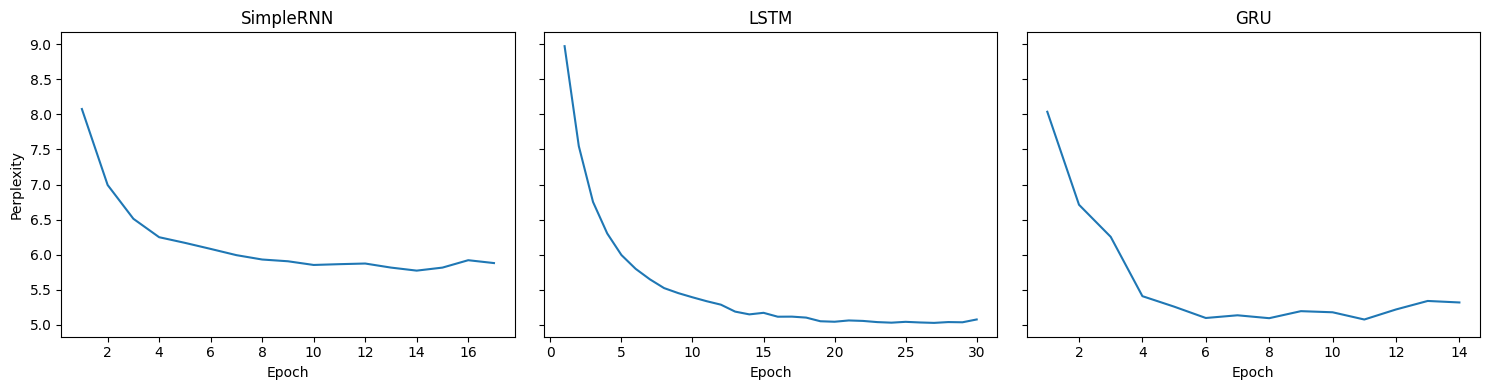

Perplejidad mínima:
  SimpleRNN : 5.77
  LSTM      : 5.03
  GRU       : 5.08


In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, ppl, name in zip(axes, [ppl_rnn, ppl_lstm, ppl_gru], ['SimpleRNN', 'LSTM', 'GRU']):
    sns.lineplot(x=range(1, len(ppl)+1), y=ppl, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Perplexity')

plt.tight_layout()
plt.show()

print(f'Perplejidad mínima:')
print(f'  SimpleRNN : {min(ppl_rnn):.2f}')
print(f'  LSTM      : {min(ppl_lstm):.2f}')
print(f'  GRU       : {min(ppl_gru):.2f}')

El gráfico muestra la evolución de la perplejidad en validación para cada arquitectura. LSTM y GRU típicamente convergen a valores menores que SimpleRNN, confirmando que sus mecanismos de memoria son ventajosos para modelado de secuencias de caracteres. Se selecciona el modelo con menor perplejidad final para la generación de secuencias.

In [47]:
best_name = min(
    [('dylan_rnn', min(ppl_rnn)), ('dylan_lstm', min(ppl_lstm)), ('dylan_gru', min(ppl_gru))],
    key=lambda x: x[1]
)[0]

best_model = keras.models.load_model(f'{best_name}.keras')
print(f'Modelo seleccionado: {best_name}')

Modelo seleccionado: dylan_lstm


In [50]:
def encode_d(text, max_length=max_ctx):
    encoded = [char2idx_d[ch] for ch in text if ch in char2idx_d]
    return pad_sequences([encoded], maxlen=max_length, padding='pre')

def decode_d(seq):
    return ''.join([idx2char_d[int(ch)] for ch in seq if int(ch) in idx2char_d])

### Greedy Search

In [51]:
def greedy_search(model, seed, n_chars):
    output = seed
    for _ in range(n_chars):
        encoded = encode_d(output)
        y_hat = np.argmax(model.predict(encoded, verbose=0)[0, -1, :])
        output += idx2char_d[y_hat]
    return output

seeds = ['how does it feel', 'blowing in the wind', 'the times they are']
for seed in seeds:
    print(f'Seed: "{seed}"')
    print(greedy_search(best_model, seed, 80))
    print()

Seed: "how does it feel"
how does it feel
to be stuck inside of my mind

i can have to serve somebody
well, i can’t let g

Seed: "blowing in the wind"
blowing in the window
and i can’t let go and i can’t let go, won’t let go, won’t let go, won’t let 

Seed: "the times they are"
the times they are a-changin’ on the morning of the street

well, i can’t let go and i can’t let g



El greedy search selecciona en cada paso el carácter con mayor probabilidad. Es determinístico: la misma semilla siempre produce la misma salida. Tiende a generar secuencias repetitivas ya que el modelo converge hacia los patrones más frecuentes del corpus (espacios, letras comunes, palabras cortas).

In [52]:
from scipy.special import softmax as sp_softmax

def select_candidates_d(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    pred_large = []
    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1e-10) + history_probs[idx])
    pred_large = np.array(pred_large)

    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        idx_select = np.random.choice(
            np.arange(pred_large.shape[0]), num_beams,
            p=sp_softmax(pred_large / temp)
        )
    else:
        raise ValueError(f'Mode {mode} not supported.')

    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select // vocab_size],
         np.array([idx_select % vocab_size]).T),
        axis=1
    )
    return pred_large[idx_select], new_history_tokens.astype(int)


def beam_search_d(model, num_beams, num_words, input_text, temp=1, mode='det'):
    encoded = encode_d(input_text)
    y_hat = model.predict(encoded, verbose=0)[0, -1, :]
    vocab_size = y_hat.shape[0]

    history_probs  = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates_d(
        [y_hat], num_beams, vocab_size, history_probs, history_tokens, temp, mode
    )

    for i in range(num_words - 1):
        preds = []
        for hist in history_tokens:
            input_update = np.array([hist[i + 1:]]).copy()
            preds.append(model.predict(input_update, verbose=0)[0, -1, :])
        history_probs, history_tokens = select_candidates_d(
            preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode
        )

    return history_tokens[:, -(len(input_text) + num_words):]

### Beam Search Determinístico

In [53]:
seed = 'how does it feel'
salidas_det = beam_search_d(best_model, num_beams=5, num_words=80, input_text=seed, mode='det')

print(f'Seed: "{seed}"\n')
for i, s in enumerate(salidas_det):
    print(f'Beam {i+1}: {decode_d(s)}')
    print()

Seed: "how does it feel"

Beam 1: how does it feel
to serve somebody, yes, you’re gonna have to serve somebody, yes, i don’t know 

Beam 2: how does it feel
to serve somebody, yes indeed
you’re gonna have to serve somebody, yes, i don’t

Beam 3: how does it feel
to serve somebody, yes indeed
you’re gonna have to serve somebody
well, it may 

Beam 4: how does it feel
to serve somebody, yes indeed
you’re gonna have to serve somebody
well, you may

Beam 5: how does it feel
to serve somebody, yes indeed
you’re gonna have to serve somebody, yes, i was a



El beam search determinístico mantiene las `num_beams` secuencias más probables en cada paso en lugar de comprometerse con una sola elección (como hace greedy). Esto permite explorar caminos alternativos y produce secuencias más variadas y coherentes que greedy. Sin embargo, al ser determinístico, siempre devuelve los mismos resultados para la misma semilla.

### Beam Search Estocástico y efecto de la temperatura

En lugar de seleccionar las mejores `num_beams` candidatas de forma greedy, el beam search estocástico muestrea con probabilidad proporcional a los log-probs escalados por la temperatura `T`:

- **T < 1**: distribución más concentrada → secuencias más conservadoras y repetitivas.
- **T = 1**: distribución original del modelo.
- **T > 1**: distribución más uniforme → mayor diversidad pero menor coherencia.

In [54]:
seed = 'how does it feel'
temps = [0.3, 1.0, 2.0]

for temp in temps:
    np.random.seed(42)
    salidas = beam_search_d(best_model, num_beams=5, num_words=80,
                            input_text=seed, temp=temp, mode='sto')
    print(f'=== Temperatura = {temp} ===')
    for i, s in enumerate(salidas[:3]):
        print(f'  Beam {i+1}: {decode_d(s)}')
    print()

=== Temperatura = 0.3 ===
  Beam 1: how does it feel
to be stuck inside of my mind
and i can’t let go, won’t let go, won’t let go, w
  Beam 2: how does it feel
to be stuck inside of my mind
and i can’t let go, won’t let go, won’t let go, w
  Beam 3: how does it feel
to be stuck inside of my mind
and i can’t let go, won’t let go, won’t let go, w

=== Temperatura = 1.0 ===
  Beam 1: how does it feel like them in the other, there’s a slow, slow train comin’ up and they speak
the
  Beam 2: how does it feel like them in the other, there’s a slow, slow train comin’ up and they speak
the
  Beam 3: how does it feel like them in the other, there’s a slow, slow train comin’ up and they speak
the

=== Temperatura = 2.0 ===
  Beam 1: how does it feel lookin’
out, but i know it’s your brain?

well, they’re still always the day
it
  Beam 2: how does it feel lookin’
out, but i know it’s your brain?

well, they’re still always the day
is
  Beam 3: how does it feel lookin’
out, but i know it’s your bra

**T=0.3**: las secuencias son muy similares entre los beams y tienden a repetir las palabras más frecuentes del corpus. El texto generado es predecible pero poco interesante.

**T=1.0**: balance entre coherencia y variedad. Los beams divergen moderadamente entre sí y el texto mantiene cierta estructura lírica.

**T=2.0**: alta entropía en el muestreo. Los beams son muy distintos entre sí y el texto puede volverse incoherente, con combinaciones de caracteres poco frecuentes. La temperatura actúa como un control de creatividad vs. fidelidad al corpus.

### Conclusiones

- La tokenización por caracteres permite trabajar sin un tokenizador externo y produce un vocabulario muy compacto (~60 símbolos), lo que facilita el entrenamiento pero exige que el modelo aprenda desde fonemas hasta palabras.
- Entre las tres arquitecturas, LSTM y GRU superan a SimpleRNN en perplejidad de validación, siendo GRU una opción más eficiente cuando el corpus es pequeño.
- Greedy search es determinístico y tiende a repetirse; beam search determinístico amplía la búsqueda sin variabilidad; beam search estocástico introduce diversidad controlable mediante la temperatura.
- La temperatura es el parámetro más intuitivo para ajustar la "creatividad" del modelo: valores bajos producen texto fiel al corpus y valores altos producen texto más original pero menos coherente.